# Tree-Based Model Comparison

This notebook compares the baseline logistic regression model with tree-based machine learning models.

The goal is to evaluate whether more flexible models can improve credit risk ranking performance.

No final decision threshold is selected in this notebook. The models are compared using predicted default probabilities and ranking-based metrics.

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/cs-training.csv")
df = df.rename(columns={"Unnamed: 0": "customer_id"})

target = "SeriousDlqin2yrs"

assert df.shape[0] == 150000, "数据行数不是150000，请检查文件"
assert df[target].isna().sum() == 0, "目标变量存在缺失，请检查数据"

df.loc[df["age"] == 0, "age"] = np.nan

delinquency_columns = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
]

for column in delinquency_columns:
    df[column] = df[column].replace([96, 98], np.nan)

X = df.drop(columns=["customer_id", target])
y = df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Training default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Training set: (120000, 10)
Test set: (30000, 10)
Training default rate: 0.06684166666666666
Test default rate: 0.06683333333333333


## Models to Compare

This notebook compares three models:

1. Logistic Regression  
   - Simple and interpretable baseline model.

2. Random Forest  
   - Tree-based ensemble model that can capture non-linear relationships.

3. Histogram Gradient Boosting  
   - Boosting model that often performs well on structured tabular data.

The comparison focuses on predicted probabilities rather than hard classifications.

建立三个模型

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

logistic_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler())
    ])),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

random_forest_model = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median", add_indicator=True)),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=50,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ))
])

gradient_boosting_model = Pipeline([
    ("preprocessor", SimpleImputer(strategy="median", add_indicator=True)),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "Histogram Gradient Boosting": gradient_boosting_model
}

训练并比较模型

In [5]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

comparison_results = []
fitted_models = {}
predicted_probabilities = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)
    y_probability = model.predict_proba(X_test)[:, 1]

    fitted_models[model_name] = model
    predicted_probabilities[model_name] = y_probability

    prediction_results = pd.DataFrame({
        "actual_result": y_test.values,
        "predicted_probability": y_probability
    })

    prediction_results["risk_decile"] = (
        pd.qcut(
            prediction_results["predicted_probability"],
            q=10,
            labels=False,
            duplicates="drop"
        ) + 1
    )

    top_decile = prediction_results["risk_decile"].max()

    top_decile_default_rate = prediction_results.loc[
        prediction_results["risk_decile"] == top_decile,
        "actual_result"
    ].mean()

    comparison_results.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, y_probability),
        "average_precision": average_precision_score(y_test, y_probability),
        "brier_score": brier_score_loss(y_test, y_probability),
        "top_decile_default_rate": top_decile_default_rate
    })

comparison_table = pd.DataFrame(comparison_results)

comparison_table = comparison_table.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

comparison_table

Training Logistic Regression...
Training Random Forest...
Training Histogram Gradient Boosting...


,model,roc_auc,average_precision,brier_score,top_decile_default_rate
0,Histogram Gradient Boosting,0.868104,0.408343,0.048641,0.370000
1,Random Forest,0.866730,0.400661,0.049011,0.369333
2,Logistic Regression,0.820503,0.359819,0.052283,0.347000


roc_auc：越高越好。

average_precision：越高越好，尤其适合违约样本少的情况。

brier_score：越低越好。

top_decile_default_rate：最高风险 10% 客户的真实违约率，越高越说明模型能抓高风险客户。

画模型对比图

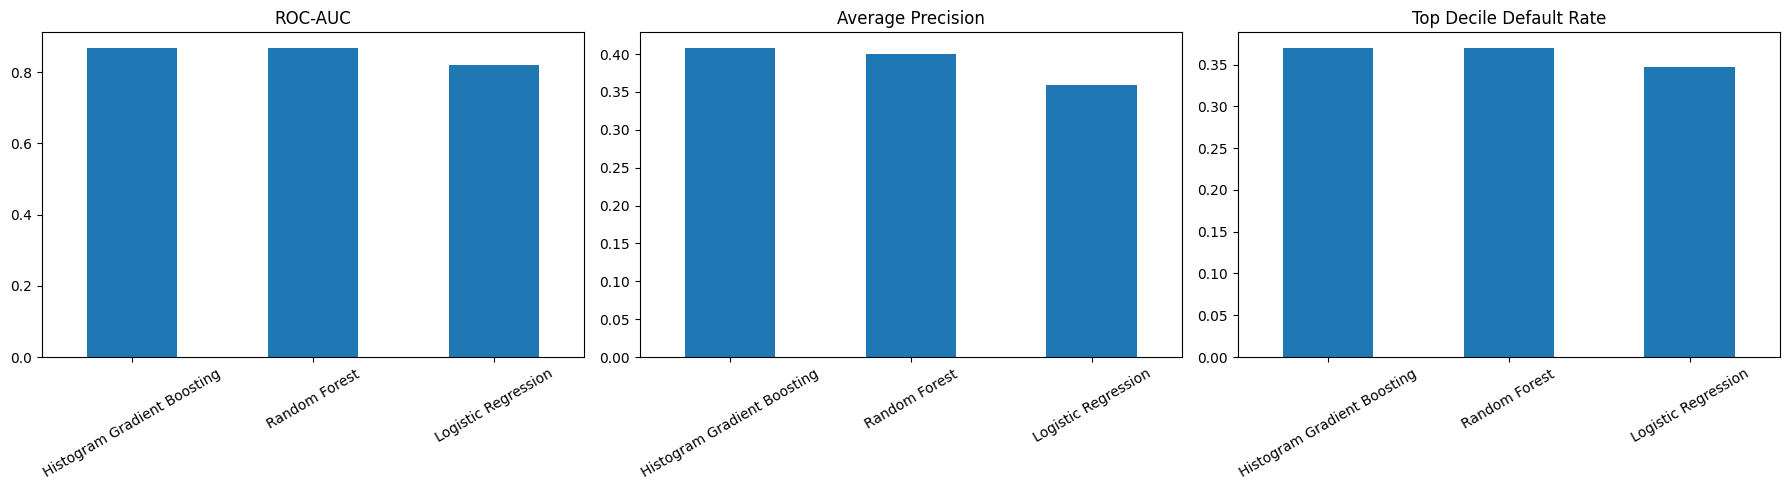

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_table.plot(
    x="model",
    y="roc_auc",
    kind="bar",
    ax=axes[0],
    legend=False,
    title="ROC-AUC"
)

comparison_table.plot(
    x="model",
    y="average_precision",
    kind="bar",
    ax=axes[1],
    legend=False,
    title="Average Precision"
)

comparison_table.plot(
    x="model",
    y="top_decile_default_rate",
    kind="bar",
    ax=axes[2],
    legend=False,
    title="Top Decile Default Rate"
)

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

查看最佳模型的风险分层

In [7]:
best_model_name = comparison_table.loc[0, "model"]
best_probability = predicted_probabilities[best_model_name]

print("Best model:", best_model_name)

best_prediction_results = pd.DataFrame({
    "actual_result": y_test.values,
    "predicted_probability": best_probability
})

best_prediction_results["risk_decile"] = (
    pd.qcut(
        best_prediction_results["predicted_probability"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1
)

best_decile_summary = best_prediction_results.groupby("risk_decile").agg(
    customer_count=("actual_result", "count"),
    default_count=("actual_result", "sum"),
    observed_default_rate=("actual_result", "mean"),
    average_predicted_probability=("predicted_probability", "mean")
).reset_index()

best_decile_summary["observed_default_rate"] = best_decile_summary["observed_default_rate"] * 100
best_decile_summary["average_predicted_probability"] = best_decile_summary["average_predicted_probability"] * 100

best_decile_summary.sort_values("risk_decile", ascending=False)

Best model: Histogram Gradient Boosting


,risk_decile,customer_count,default_count,observed_default_rate,average_predicted_probability
9,10,3000,1110,37.000000,36.570930
8,9,3000,354,11.800000,11.863643
7,8,3000,220,7.333333,6.453724
6,7,3000,106,3.533333,4.043583
5,6,3000,69,2.300000,2.671472
4,5,3000,60,2.000000,1.815721
3,4,3000,31,1.033333,1.323471
2,3,3000,25,0.833333,1.024571
1,2,3000,20,0.666667,0.766231
0,1,3000,10,0.333333,0.515730


画最佳模型的风险分层图

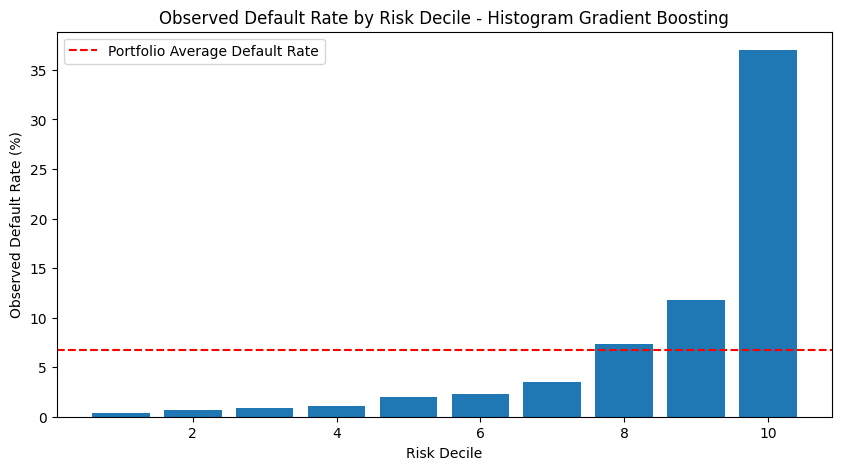

In [8]:
decile_plot_data = best_decile_summary.sort_values("risk_decile")

plt.figure(figsize=(10, 5))

plt.bar(
    decile_plot_data["risk_decile"],
    decile_plot_data["observed_default_rate"]
)

plt.axhline(
    y=y_test.mean() * 100,
    color="red",
    linestyle="--",
    label="Portfolio Average Default Rate"
)

plt.xlabel("Risk Decile")
plt.ylabel("Observed Default Rate (%)")
plt.title(f"Observed Default Rate by Risk Decile - {best_model_name}")
plt.legend()
plt.show()

## Model Comparison Summary

This notebook compares logistic regression with tree-based models for credit risk prediction.

The models are evaluated using predicted default probabilities rather than fixed decision thresholds.

The comparison focuses on:

- ROC-AUC
- Average Precision
- Brier Score
- Observed default rate in the highest-risk decile

The best-performing model is selected based on its ability to rank customers by credit risk.

No final decision threshold is selected in this notebook. Threshold selection, calibration, and model validation will be handled in the next stage.

## Key Findings

Histogram Gradient Boosting is the best-performing model in this comparison.

It achieves the highest ROC-AUC of 0.8681, the highest Average Precision of 0.4083, and the lowest Brier Score of 0.0486.

The top 10% highest-risk customers identified by this model have an observed default rate of 37.0%, compared with the portfolio average default rate of 6.68%.

This suggests that tree-based models can improve credit risk ranking performance compared with the baseline logistic regression model.

No final decision threshold is selected in this notebook. Threshold selection, calibration, and model validation will be handled in the next stage.